# 01 — Data Overview

Connects to the real Databricks deployment data and produces a complete overview of the `gateway_scan_telemetry` table.

**Sections:**
1. Connection setup
2. Gateway overview
3. RSSI distribution
4. Temporal pattern
5. Multi-hub visibility

All plots are saved to `outputs/`.

## Section 1 — Connection Setup

Credentials are loaded from a `.env` file in the repo root using `python-dotenv`.
This avoids hardcoding credentials and works reliably across terminal sessions
and VS Code notebook kernels.

**Setup (one time only):**
1. Create a file called `.env` in the `bio-tracker/` root (already gitignored)
2. Add these three lines with no spaces around `=` and no quotes:
```
DATABRICKS_SERVER_HOSTNAME=dbc-116b948a-d644.cloud.databricks.com
DATABRICKS_HTTP_PATH=/sql/1.0/warehouses/d89ac2793b1f6d5c
DATABRICKS_TOKEN=your_token_here
```
3. Install dotenv if needed: `pip install python-dotenv`

**Important:** Cell 1 must run before Cell 2. Always run cells top to bottom
or use "Run All" — never run the connection cell without running the dotenv
cell first.

In [3]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file BEFORE any other imports
# .env lives in the repo root, one level up from analysis/
load_dotenv("../.env")

# Verify all three variables loaded correctly
print("HOSTNAME:", os.getenv("DATABRICKS_SERVER_HOSTNAME"))
print("HTTP_PATH:", os.getenv("DATABRICKS_HTTP_PATH"))
print("TOKEN set:", os.getenv("DATABRICKS_TOKEN") is not None)

HOSTNAME: dbc-116b948a-d644.cloud.databricks.com
HTTP_PATH: /sql/1.0/warehouses/d89ac2793b1f6d5c
TOKEN set: True


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from databricks import sql

# Output directory for saved plots
OUTPUT_DIR = "../outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Table reference
TABLE = "etl_device_telemetry_bronze.gateway_scan_telemetry"

# Seaborn style for all plots
sns.set_theme(style="darkgrid")

print("Libraries loaded.")

# Connect to Databricks using environment variables
# sql.connect() returns a connection object — we use it as a context manager (with statement)
# so it closes automatically when we're done
connection = sql.connect(
    server_hostname = os.getenv("DATABRICKS_SERVER_HOSTNAME"),
    http_path       = os.getenv("DATABRICKS_HTTP_PATH"),
    access_token    = os.getenv("DATABRICKS_TOKEN")
)

print("Connected to Databricks.")

def run_query(query: str) -> pd.DataFrame:
    """Run a SQL query and return results as a pandas DataFrame."""
    with connection.cursor() as cursor:
        cursor.execute(query)
        # cursor.fetchall() returns a list of Row objects
        # .asDict() converts each Row to a plain Python dict
        # pd.DataFrame() then turns the list of dicts into a DataFrame
        return pd.DataFrame([row.asDict() for row in cursor.fetchall()])

# Quick sanity check
test = run_query("SELECT 1 AS test")
print("Sanity check:", test)

Libraries loaded.
Connected to Databricks.
Sanity check:    test
0     1


## Section 2 — Gateway Overview

In [5]:
# Pull per-gateway summary statistics
# Exclude the test gateway which has artificial -20 RSSI values
gateway_query = """
SELECT
    gateway_id,
    COUNT(*)                          AS total_readings,
    COUNT(DISTINCT scanned_device_id) AS unique_devices,
    ROUND(AVG(rssi), 1)               AS avg_rssi,
    MIN(reported_scan_timestamp)      AS earliest,
    MAX(reported_scan_timestamp)      AS latest
FROM etl_device_telemetry_bronze.gateway_scan_telemetry
WHERE gateway_id != 'bio_id_test_scan_results'
GROUP BY gateway_id
ORDER BY total_readings DESC
"""

gateways = run_query(gateway_query)

# Parse timestamps
gateways["earliest"] = pd.to_datetime(gateways["earliest"])
gateways["latest"]   = pd.to_datetime(gateways["latest"])

print(f"Total gateways: {len(gateways)}")
print(f"Total readings across all gateways: {gateways['total_readings'].sum():,}")
gateways.head(15)

Total gateways: 19885
Total readings across all gateways: 11,381,447


,gateway_id,total_readings,unique_devices,avg_rssi,earliest,latest
0,3660350095,1385625,21,-70.8,2023-04-28 03:14:25+00:00,2025-02-27 07:30:52+00:00
1,3773013105,1031308,26,-67.7,2023-08-03 05:04:32+00:00,2025-02-27 07:31:53+00:00
2,2399415635,602933,166,-85.2,2023-10-17 17:49:49+00:00,2024-12-10 02:27:13+00:00
3,1452965412,332658,118,-61.5,2023-09-27 17:34:10+00:00,2024-08-20 18:30:14+00:00
4,1801985138,317685,128,-81.0,2023-07-21 20:32:34+00:00,2024-05-21 05:55:04+00:00
5,2194910495,311740,110,-84.8,2023-10-16 20:57:16+00:00,2024-03-29 15:35:12+00:00
6,3767466007,308224,115,-71.9,2023-10-16 20:58:01+00:00,2026-04-28 20:21:49+00:00
7,560675722,266576,120,-75.9,2023-09-11 21:48:25+00:00,2024-08-18 16:12:57+00:00
8,3863633463,231136,127,-73.4,2023-10-16 20:58:41+00:00,2026-06-02 02:09:27+00:00
9,3231951397,209582,19,-60.0,2023-05-03 12:51:48+00:00,2025-11-05 13:42:54+00:00


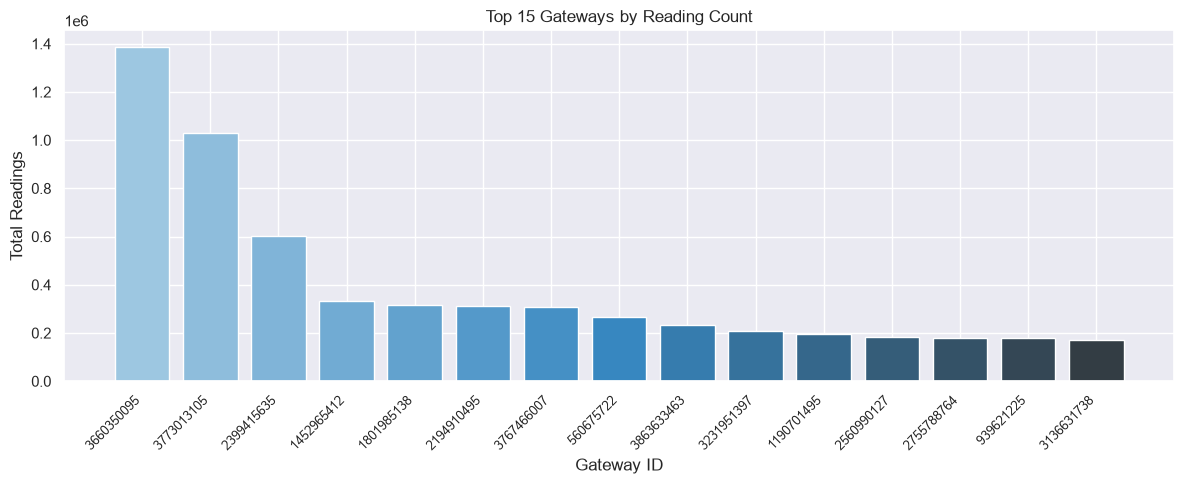

Saved: 01_gateway_reading_counts.png


In [6]:
# Bar chart: top 15 gateways by reading count
top15 = gateways.head(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(top15)), top15["total_readings"], color=sns.color_palette("Blues_d", len(top15)))
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15["gateway_id"], rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Gateway ID")
ax.set_ylabel("Total Readings")
ax.set_title("Top 15 Gateways by Reading Count")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}01_gateway_reading_counts.png", dpi=150)
plt.show()
print("Saved: 01_gateway_reading_counts.png")

## Section 3 — RSSI Distribution

In [7]:
# Pull all RSSI values, filtering out known artifacts
# RSSI > 0 is physically impossible — artifact in the data
# RSSI < -100 is below usable range
rssi_query = """
SELECT rssi
FROM etl_device_telemetry_bronze.gateway_scan_telemetry
WHERE gateway_id != 'bio_id_test_scan_results'
  AND rssi <= 0
  AND rssi >= -100
"""

rssi_df = run_query(rssi_query)
rssi_vals = rssi_df["rssi"].astype(float)

print(f"Total RSSI readings (filtered): {len(rssi_vals):,}")
print(f"Min:    {rssi_vals.min():.1f} dBm")
print(f"Max:    {rssi_vals.max():.1f} dBm")
print(f"Mean:   {rssi_vals.mean():.1f} dBm")
print(f"Median: {rssi_vals.median():.1f} dBm")
print(f"Std:    {rssi_vals.std():.1f} dB")

Total RSSI readings (filtered): 11,377,914
Min:    -100.0 dBm
Max:    -3.0 dBm
Mean:   -69.3 dBm
Median: -70.0 dBm
Std:    15.0 dB


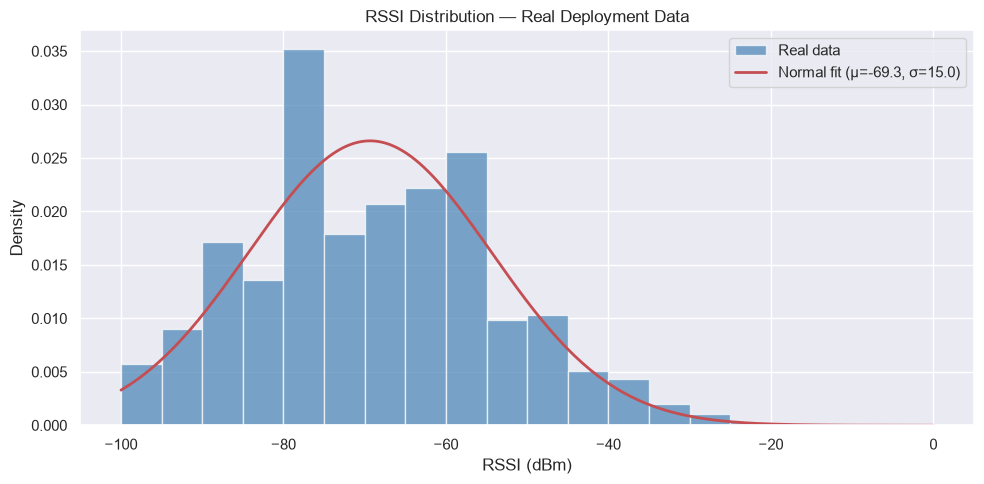

Saved: 01_rssi_distribution.png


In [8]:
# Histogram with normal distribution overlay
fig, ax = plt.subplots(figsize=(10, 5))

# Plot histogram with 5 dBm bin width
bins = range(-100, 5, 5)
ax.hist(rssi_vals, bins=bins, density=True, alpha=0.7, color="steelblue", label="Real data")

# Fit and overlay a normal distribution curve
mu, sigma = stats.norm.fit(rssi_vals)
x = np.linspace(-100, 0, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", linewidth=2,
        label=f"Normal fit (μ={mu:.1f}, σ={sigma:.1f})")

ax.set_xlabel("RSSI (dBm)")
ax.set_ylabel("Density")
ax.set_title("RSSI Distribution — Real Deployment Data")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}01_rssi_distribution.png", dpi=150)
plt.show()
print("Saved: 01_rssi_distribution.png")

## Section 4 — Temporal Pattern

We expect each gateway to report on a fixed ~10 minute clock with a stable offset from the hour. This section visualises that pattern and confirms the per-gateway offset is fixed over time — the key finding that justifies the 20-minute bucketing window.

In [9]:
# Use the most active gateway
top_gateway = gateways.iloc[0]["gateway_id"]
print(f"Analysing most active gateway: {top_gateway}")

temporal_query = f"""
SELECT
    reported_scan_timestamp,
    scanned_device_id
FROM etl_device_telemetry_bronze.gateway_scan_telemetry
WHERE gateway_id = '{top_gateway}'
ORDER BY reported_scan_timestamp DESC
LIMIT 5000
"""

temporal_df = run_query(temporal_query)
temporal_df["reported_scan_timestamp"] = pd.to_datetime(temporal_df["reported_scan_timestamp"])
print(f"Rows: {len(temporal_df)}")
temporal_df.head()

Analysing most active gateway: 3660350095
Rows: 5000


,reported_scan_timestamp,scanned_device_id
0,2025-02-27 07:30:52+00:00,t150e45011545790138151801
1,2025-02-27 07:30:52+00:00,t6f0a73016f733851380d1801
2,2025-02-27 07:30:52+00:00,t0804380108383d0138101401
3,2025-02-27 07:30:52+00:00,t2d0c47012d47586138111801
4,2025-02-27 07:30:52+00:00,t1305010113011d11381c1401


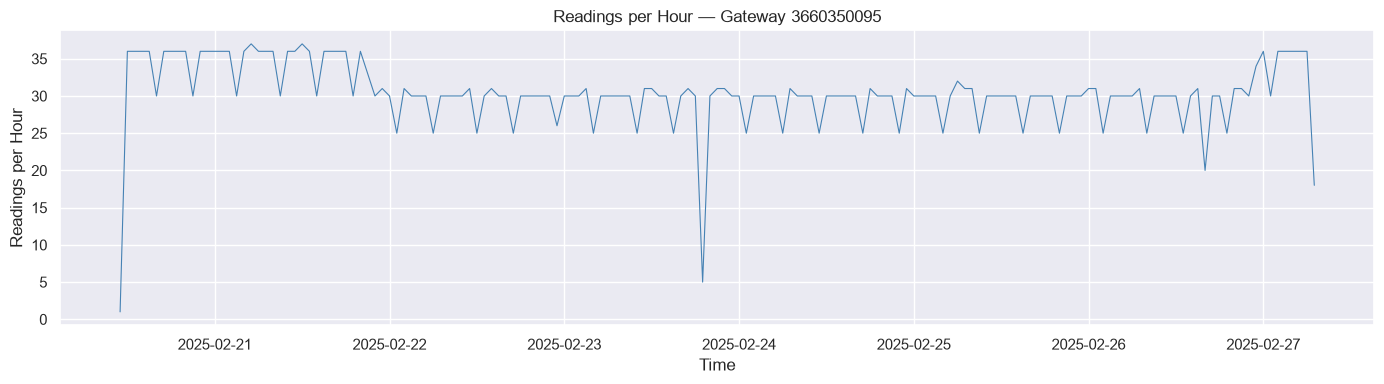

In [11]:
# Plot readings per hour to reveal the 10-minute cadence
temporal_df["hour"] = temporal_df["reported_scan_timestamp"].dt.floor("h")
hourly = temporal_df.groupby("hour").size().reset_index(name="readings")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hourly["hour"], hourly["readings"], linewidth=0.8, color="steelblue")
ax.set_xlabel("Time")
ax.set_ylabel("Readings per Hour")
ax.set_title(f"Readings per Hour — Gateway {top_gateway}")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}01_temporal_pattern.png", dpi=150)
plt.show()

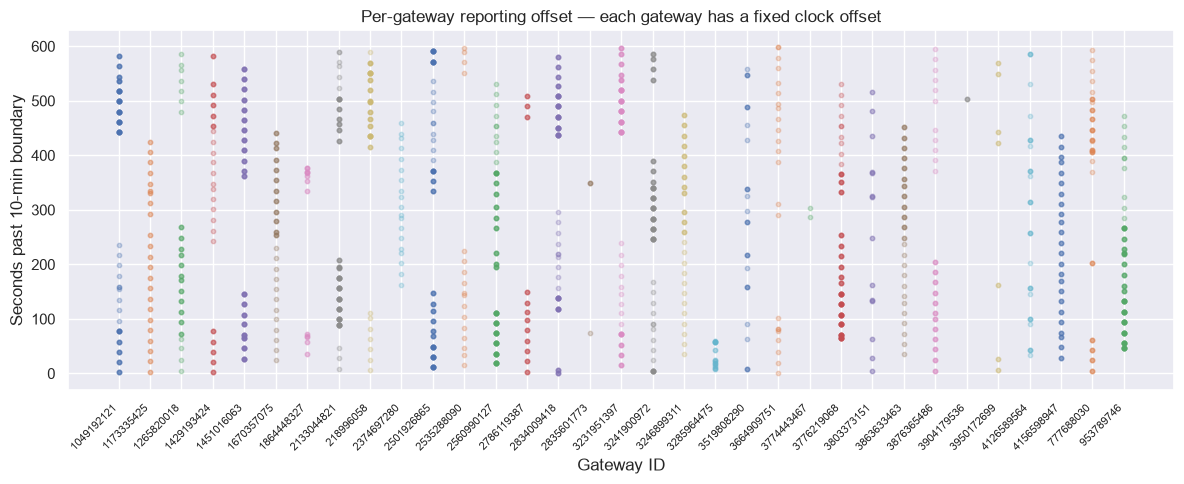

Saved: 01_gateway_clock_offsets.png


In [12]:
# Show per-gateway clock offset distribution
# For each timestamp, extract seconds past the nearest 10-minute boundary
# A fixed offset means the histogram should show a sharp spike at one value

offset_query = """
SELECT
    gateway_id,
    reported_scan_timestamp
FROM etl_device_telemetry_bronze.gateway_scan_telemetry
WHERE gateway_id != 'bio_id_test_scan_results'
  AND reported_scan_timestamp >= '2025-03-04T14:00:00Z'
  AND reported_scan_timestamp <  '2025-03-04T18:00:00Z'
"""

offset_df = run_query(offset_query)
offset_df["reported_scan_timestamp"] = pd.to_datetime(offset_df["reported_scan_timestamp"])

# Seconds past the nearest 10-minute boundary
offset_df["seconds_past_10min"] = (
    offset_df["reported_scan_timestamp"].dt.minute % 10 * 60
    + offset_df["reported_scan_timestamp"].dt.second
)

# Plot per-gateway offset as a strip plot — each gateway should cluster tightly
fig, ax = plt.subplots(figsize=(12, 5))
for gw_id, group in offset_df.groupby("gateway_id"):
    ax.scatter(
        [gw_id] * len(group),
        group["seconds_past_10min"],
        alpha=0.3, s=10
    )
ax.set_xlabel("Gateway ID")
ax.set_ylabel("Seconds past 10-min boundary")
ax.set_title("Per-gateway reporting offset — each gateway has a fixed clock offset")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}01_gateway_clock_offsets.png", dpi=150)
plt.show()
print("Saved: 01_gateway_clock_offsets.png")

## Section 5 — Multi-Hub Visibility

The pipeline depends on devices being seen by multiple hubs simultaneously.
This section measures how often that happens in the real data.

In [13]:
# For each (device, timestamp) pair, count how many gateways saw that device
# Note: timestamps here are exact — we're counting simultaneous visibility
# before any bucketing is applied
visibility_query = """
SELECT
    scanned_device_id,
    reported_scan_timestamp,
    COUNT(DISTINCT gateway_id) AS hubs_seen_by
FROM etl_device_telemetry_bronze.gateway_scan_telemetry
WHERE gateway_id != 'bio_id_test_scan_results'
GROUP BY scanned_device_id, reported_scan_timestamp
"""

visibility_df = run_query(visibility_query)
print(f"Total (device, timestamp) pairs: {len(visibility_df):,}")
print("\nDistribution of hub counts per observation:")
print(visibility_df["hubs_seen_by"].value_counts().sort_index())

Total (device, timestamp) pairs: 10,592,915

Distribution of hub counts per observation:
hubs_seen_by
1    10535153
2       56392
3        1286
4          69
5          15
Name: count, dtype: int64


Observations with 2+ hubs: 0.5%
Observations with 5+ hubs: 0.0%


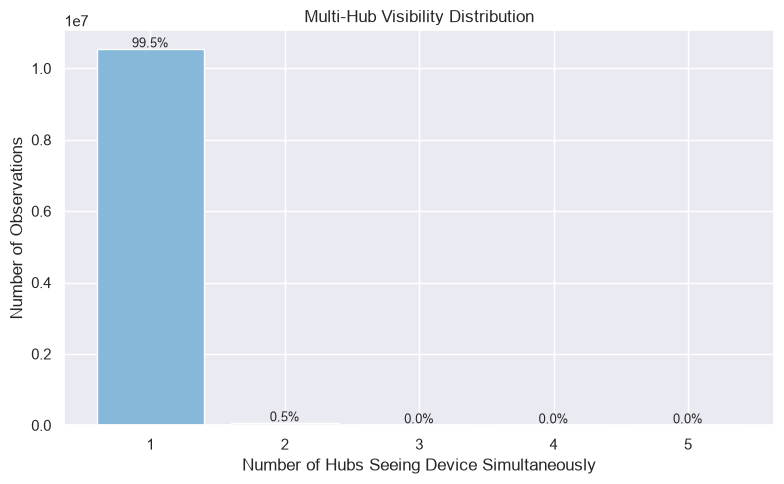

Saved: 01_multi_hub_visibility.png


In [14]:
# % of observations with multi-hub visibility — critical pipeline metric
multi_hub_pct = (visibility_df["hubs_seen_by"] >= 2).mean() * 100
five_plus_pct = (visibility_df["hubs_seen_by"] >= 5).mean() * 100

print(f"Observations with 2+ hubs: {multi_hub_pct:.1f}%")
print(f"Observations with 5+ hubs: {five_plus_pct:.1f}%")

# Histogram of hub counts
fig, ax = plt.subplots(figsize=(8, 5))
counts = visibility_df["hubs_seen_by"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=sns.color_palette("Blues_d", len(counts)))
ax.set_xlabel("Number of Hubs Seeing Device Simultaneously")
ax.set_ylabel("Number of Observations")
ax.set_title("Multi-Hub Visibility Distribution")
ax.set_xticks(counts.index)

# Annotate bars with percentages
total = counts.sum()
for x, y in zip(counts.index, counts.values):
    ax.text(x, y + total * 0.005, f"{y/total*100:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}01_multi_hub_visibility.png", dpi=150)
plt.show()
print("Saved: 01_multi_hub_visibility.png")

In [15]:
# Close the connection when done
connection.close()
print("Connection closed. All outputs saved to outputs/.")

Connection closed. All outputs saved to outputs/.
